# No Augmentation + 5 fold CV

In [ ]:
!pip install -q grad-cam
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:


# 1. Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Drive & Params
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/safe-llm-for-women'

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5
N_SPLITS = 5
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 3. Standard Transform (No random augmentations)
standard_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Full dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=standard_transforms)
raw_dataset = datasets.ImageFolder(root=DATA_DIR, transform=None)
class_names = full_dataset.classes
all_targets = np.array(full_dataset.targets)

print(f"Classes: {class_names}")
print(f"Total samples: {len(full_dataset)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda:0
Classes: ['pause', 'proceed']
Total samples: 267


In [ ]:
def build_model(model_name, num_classes=2):
    """Initializes standard backbones with matching classification heads and targets for Grad-CAM."""
    if model_name == 'ResNet18':
        net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        net.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.fc.in_features, num_classes))
        target_layer = [net.layer4[-1]]
    elif model_name == 'DenseNet121':
        net = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        net.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.classifier.in_features, num_classes))
        target_layer = [net.features[-1]]
    elif model_name == 'EfficientNet-B0':
        net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        net.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.classifier[1].in_features, num_classes))
        target_layer = [net.features[-1]]
    elif model_name == 'MobileNetV3-Large':
        net = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        net.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.classifier[0].in_features, num_classes))
        target_layer = [net.features[-1]]
    return net.to(device), target_layer

MODEL_NAMES = ['ResNet18', 'DenseNet121', 'EfficientNet-B0', 'MobileNetV3-Large']

# Storage for results across folds
cv_histories = {m: {'train_loss': np.zeros((N_SPLITS, EPOCHS)),
                    'val_loss': np.zeros((N_SPLITS, EPOCHS))} for m in MODEL_NAMES}
oof_predictions = {m: np.zeros(len(full_dataset), dtype=int) for m in MODEL_NAMES}
oof_confidences = {m: np.zeros(len(full_dataset), dtype=float) for m in MODEL_NAMES}
best_models_per_arch = {}
target_layers_dict = {}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
criterion = nn.CrossEntropyLoss()

for model_name in MODEL_NAMES:
    print(f"\n{'='*25} 5-Fold Cross Validation: {model_name} {'='*25}")
    best_overall_val_loss = float('inf')

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets)):
        set_seed(42 + fold)

        train_sub = Subset(full_dataset, train_idx)
        val_sub = Subset(full_dataset, val_idx)

        train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False)

        model, target_layer = build_model(model_name)
        if model_name not in target_layers_dict:
            target_layers_dict[model_name] = target_layer

        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

        fold_best_loss = float('inf')
        fold_best_weights = copy.deepcopy(model.state_dict())

        for epoch in range(EPOCHS):
            # Training
            model.train()
            train_loss = 0.0
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(x)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * x.size(0)

            epoch_train_loss = train_loss / len(train_sub)

            # Validation
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(device), y.to(device)
                    out = model(x)
                    loss = criterion(out, y)
                    val_loss += loss.item() * x.size(0)

            epoch_val_loss = val_loss / len(val_sub)

            cv_histories[model_name]['train_loss'][fold, epoch] = epoch_train_loss
            cv_histories[model_name]['val_loss'][fold, epoch] = epoch_val_loss

            if epoch_val_loss < fold_best_loss:
                fold_best_loss = epoch_val_loss
                fold_best_weights = copy.deepcopy(model.state_dict())

        # Load best fold model for Out-of-Fold (OOF) Inference
        model.load_state_dict(fold_best_weights)
        model.eval()
        fold_preds = []
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                probs = F.softmax(model(x), dim=1)
                preds = probs.argmax(dim=1).cpu().numpy()
                fold_preds.extend(preds)

        oof_predictions[model_name][val_idx] = fold_preds
        fold_acc = np.mean(np.array(fold_preds) == all_targets[val_idx])
        print(f"Fold {fold+1}/{N_SPLITS} | Best Val Loss: {fold_best_loss:.4f} | Val Accuracy: {fold_acc:.2%}")

        # Retain overall best model across all folds for Grad-CAM visualization
        if fold_best_loss < best_overall_val_loss:
            best_overall_val_loss = fold_best_loss
            best_models_per_arch[model_name] = copy.deepcopy(model)


========================= 5-Fold Cross Validation: ResNet18 =========================
Fold 1/5 | Best Val Loss: 0.1719 | Val Accuracy: 92.59%
Fold 2/5 | Best Val Loss: 0.1478 | Val Accuracy: 94.44%
Fold 3/5 | Best Val Loss: 0.0265 | Val Accuracy: 100.00%
Fold 4/5 | Best Val Loss: 0.1287 | Val Accuracy: 96.23%
Fold 5/5 | Best Val Loss: 0.1008 | Val Accuracy: 96.23%

========================= 5-Fold Cross Validation: DenseNet121 =========================
Fold 1/5 | Best Val Loss: 0.2333 | Val Accuracy: 92.59%
Fold 2/5 | Best Val Loss: 0.1395 | Val Accuracy: 92.59%
Fold 3/5 | Best Val Loss: 0.0270 | Val Accuracy: 100.00%
Fold 4/5 | Best Val Loss: 0.1391 | Val Accuracy: 96.23%
Fold 5/5 | Best Val Loss: 0.0800 | Val Accuracy: 98.11%

========================= 5-Fold Cross Validation: EfficientNet-B0 =========================
Fold 1/5 | Best Val Loss: 0.2092 | Val Accuracy: 92.59%
Fold 2/5 | Best Val Loss: 0.1467 | Val Accuracy: 98.15%
Fold 3/5 | Best Val Loss: 0.1044 | Val Accuracy: 98.11%

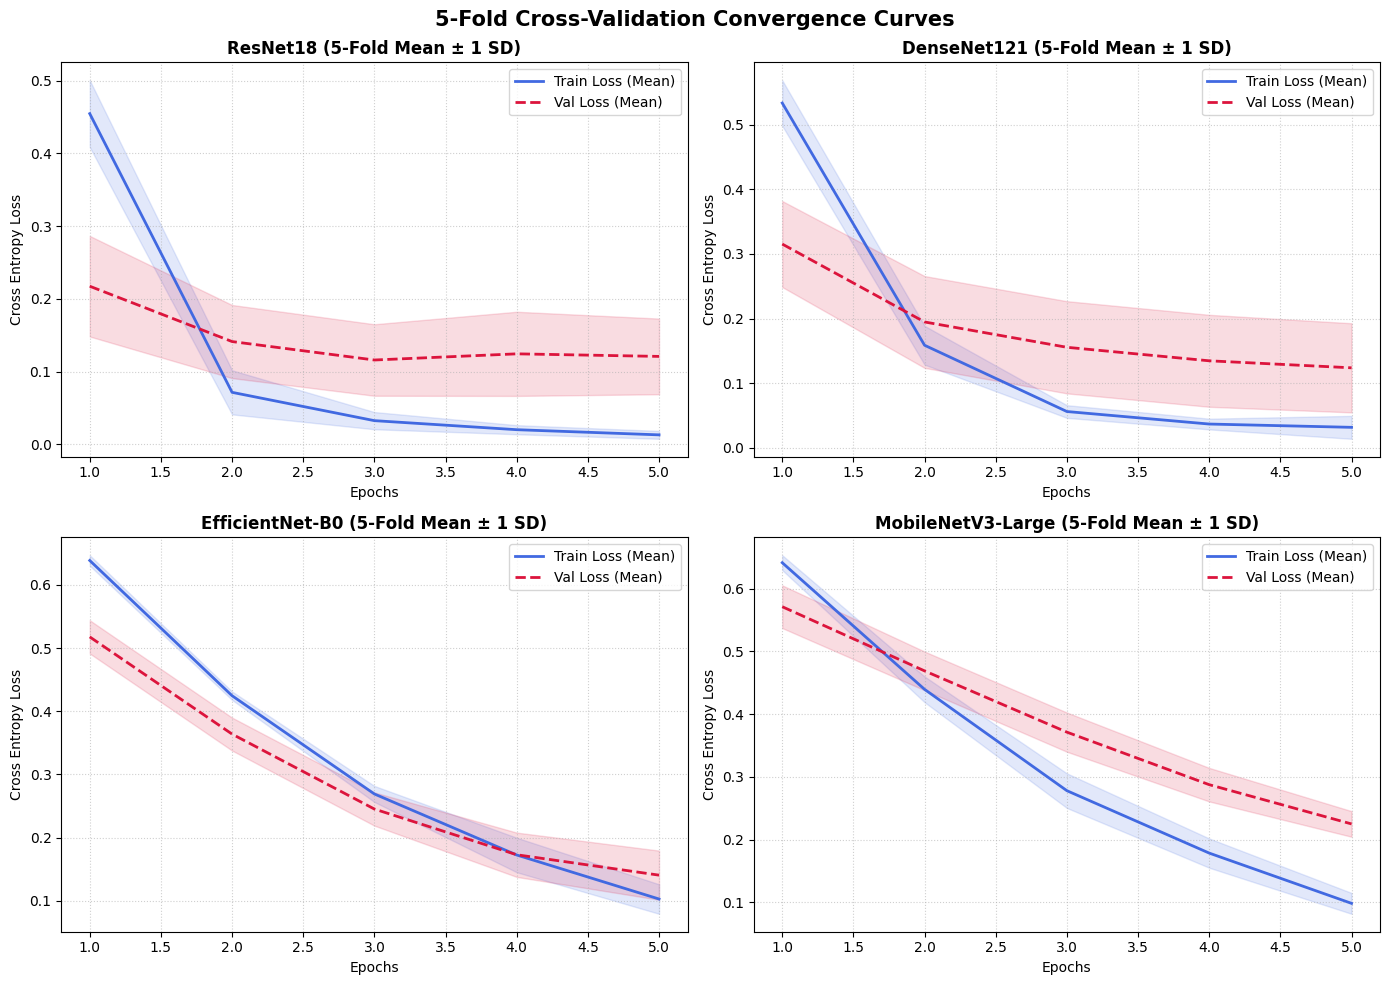

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
epochs_range = np.arange(1, EPOCHS + 1)

for i, name in enumerate(MODEL_NAMES):
    ax = axes[i]
    train_mean = cv_histories[name]['train_loss'].mean(axis=0)
    train_std = cv_histories[name]['train_loss'].std(axis=0)
    val_mean = cv_histories[name]['val_loss'].mean(axis=0)
    val_std = cv_histories[name]['val_loss'].std(axis=0)

    # Plot Means
    ax.plot(epochs_range, train_mean, label='Train Loss (Mean)', color='royalblue', lw=2)
    ax.fill_between(epochs_range, train_mean - train_std, train_mean + train_std, color='royalblue', alpha=0.15)

    ax.plot(epochs_range, val_mean, label='Val Loss (Mean)', color='crimson', lw=2, linestyle='--')
    ax.fill_between(epochs_range, val_mean - val_std, val_mean + val_std, color='crimson', alpha=0.15)

    ax.set_title(f"{name} (5-Fold Mean ± 1 SD)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Cross Entropy Loss")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')

plt.suptitle("5-Fold Cross-Validation Convergence Curves", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

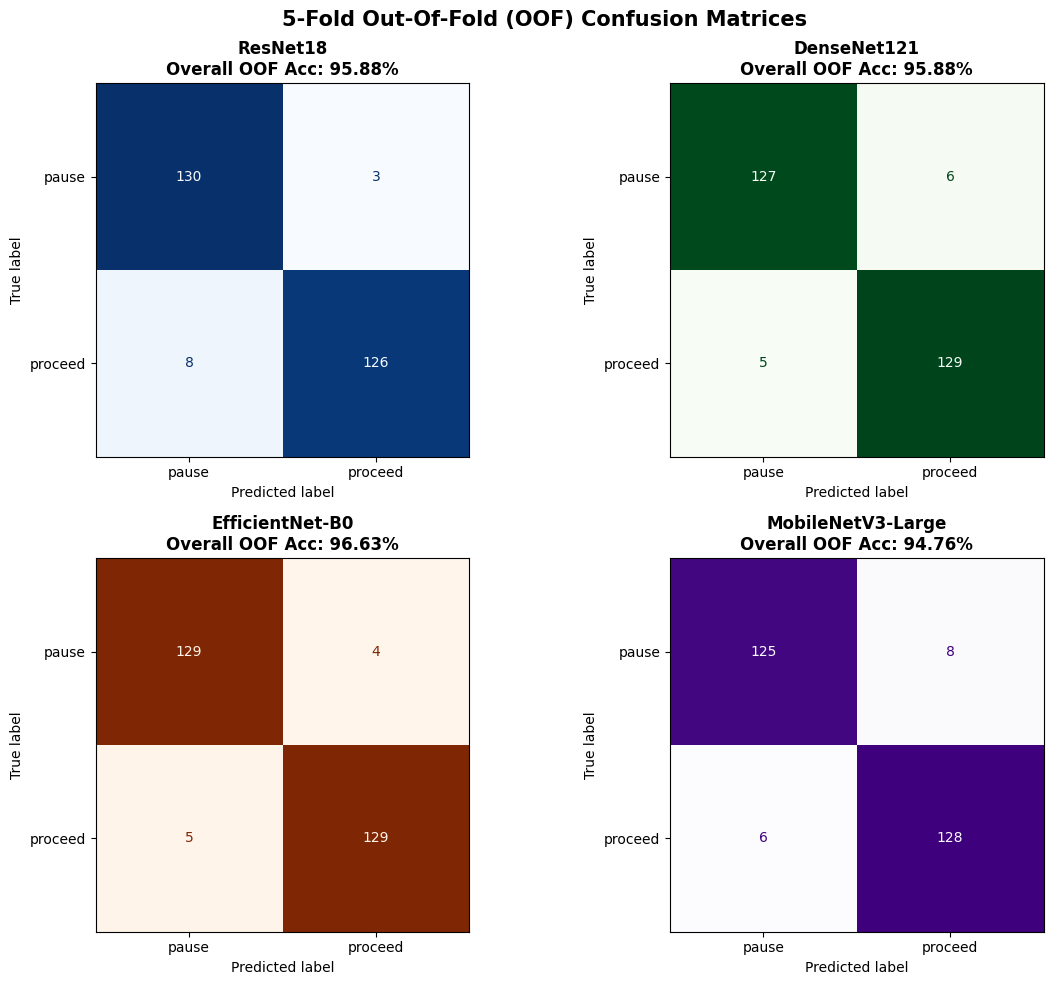


==================== ResNet18 5-Fold OOF Classification Report ====================
              precision    recall  f1-score   support

       pause       0.94      0.98      0.96       133
     proceed       0.98      0.94      0.96       134

    accuracy                           0.96       267
   macro avg       0.96      0.96      0.96       267
weighted avg       0.96      0.96      0.96       267


==================== DenseNet121 5-Fold OOF Classification Report ====================
              precision    recall  f1-score   support

       pause       0.96      0.95      0.96       133
     proceed       0.96      0.96      0.96       134

    accuracy                           0.96       267
   macro avg       0.96      0.96      0.96       267
weighted avg       0.96      0.96      0.96       267


==================== EfficientNet-B0 5-Fold OOF Classification Report ====================
              precision    recall  f1-score   support

       pause       0.96   

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
cm_colormaps = [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]

for i, name in enumerate(MODEL_NAMES):
    cm = confusion_matrix(all_targets, oof_predictions[name])
    acc = np.mean(all_targets == oof_predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap=cm_colormaps[i], colorbar=False)
    axes[i].set_title(f"{name}\nOverall OOF Acc: {acc:.2%}", fontweight='bold')

plt.suptitle("5-Fold Out-Of-Fold (OOF) Confusion Matrices", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print Out-Of-Fold Classification Reports
for name in MODEL_NAMES:
    print(f"\n==================== {name} 5-Fold OOF Classification Report ====================")
    print(classification_report(all_targets, oof_predictions[name], target_names=class_names))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Device: cuda:0
Classes: ['pause', 'proceed']
Train samples: 213 | Validation samples: 54

==================== Training ResNet18 (10 Epochs) ====================
Epoch 01/10 | Train Loss: 0.4383 Acc: 0.7746 | Val Loss: 0.2634 Acc: 0.9259
Epoch 02/10 | Train Loss: 0.0756 Acc: 0.9859 | Val Loss: 0.2033 Acc: 0.9259
Epoch 03/10 | Train Loss: 0.0853 Acc: 0.9718 | Val Loss: 0.1904 Acc: 0.9074
Epoch 04/10 | Train Loss: 0.0079 Acc: 1.0000 | Val Loss: 0.1447 Acc: 0.9074
Epoch 05/10 | Train Loss: 0.0182 Acc: 0.9953 | Val Loss: 0.1550 Acc: 0.9444
Epoch 06/10 | Train Loss: 0.0072 Acc: 1.0000 | Val Loss: 0.1605 Acc: 0.9444
Epoch 07/10 | Train Loss: 0.0106 Acc: 0.9953 | Val Loss: 0.1790 Acc: 0.9259
Epoch 08/10 | Train Loss: 0.0092 Acc: 1.0000 | Val Loss: 0.1682 Acc: 0.9259
Epoch 09/10 | Train Loss: 0.0230 Acc: 0.9906 | Val Loss: 0.1493 Acc: 0.9444
Epoch 10/10 | Train

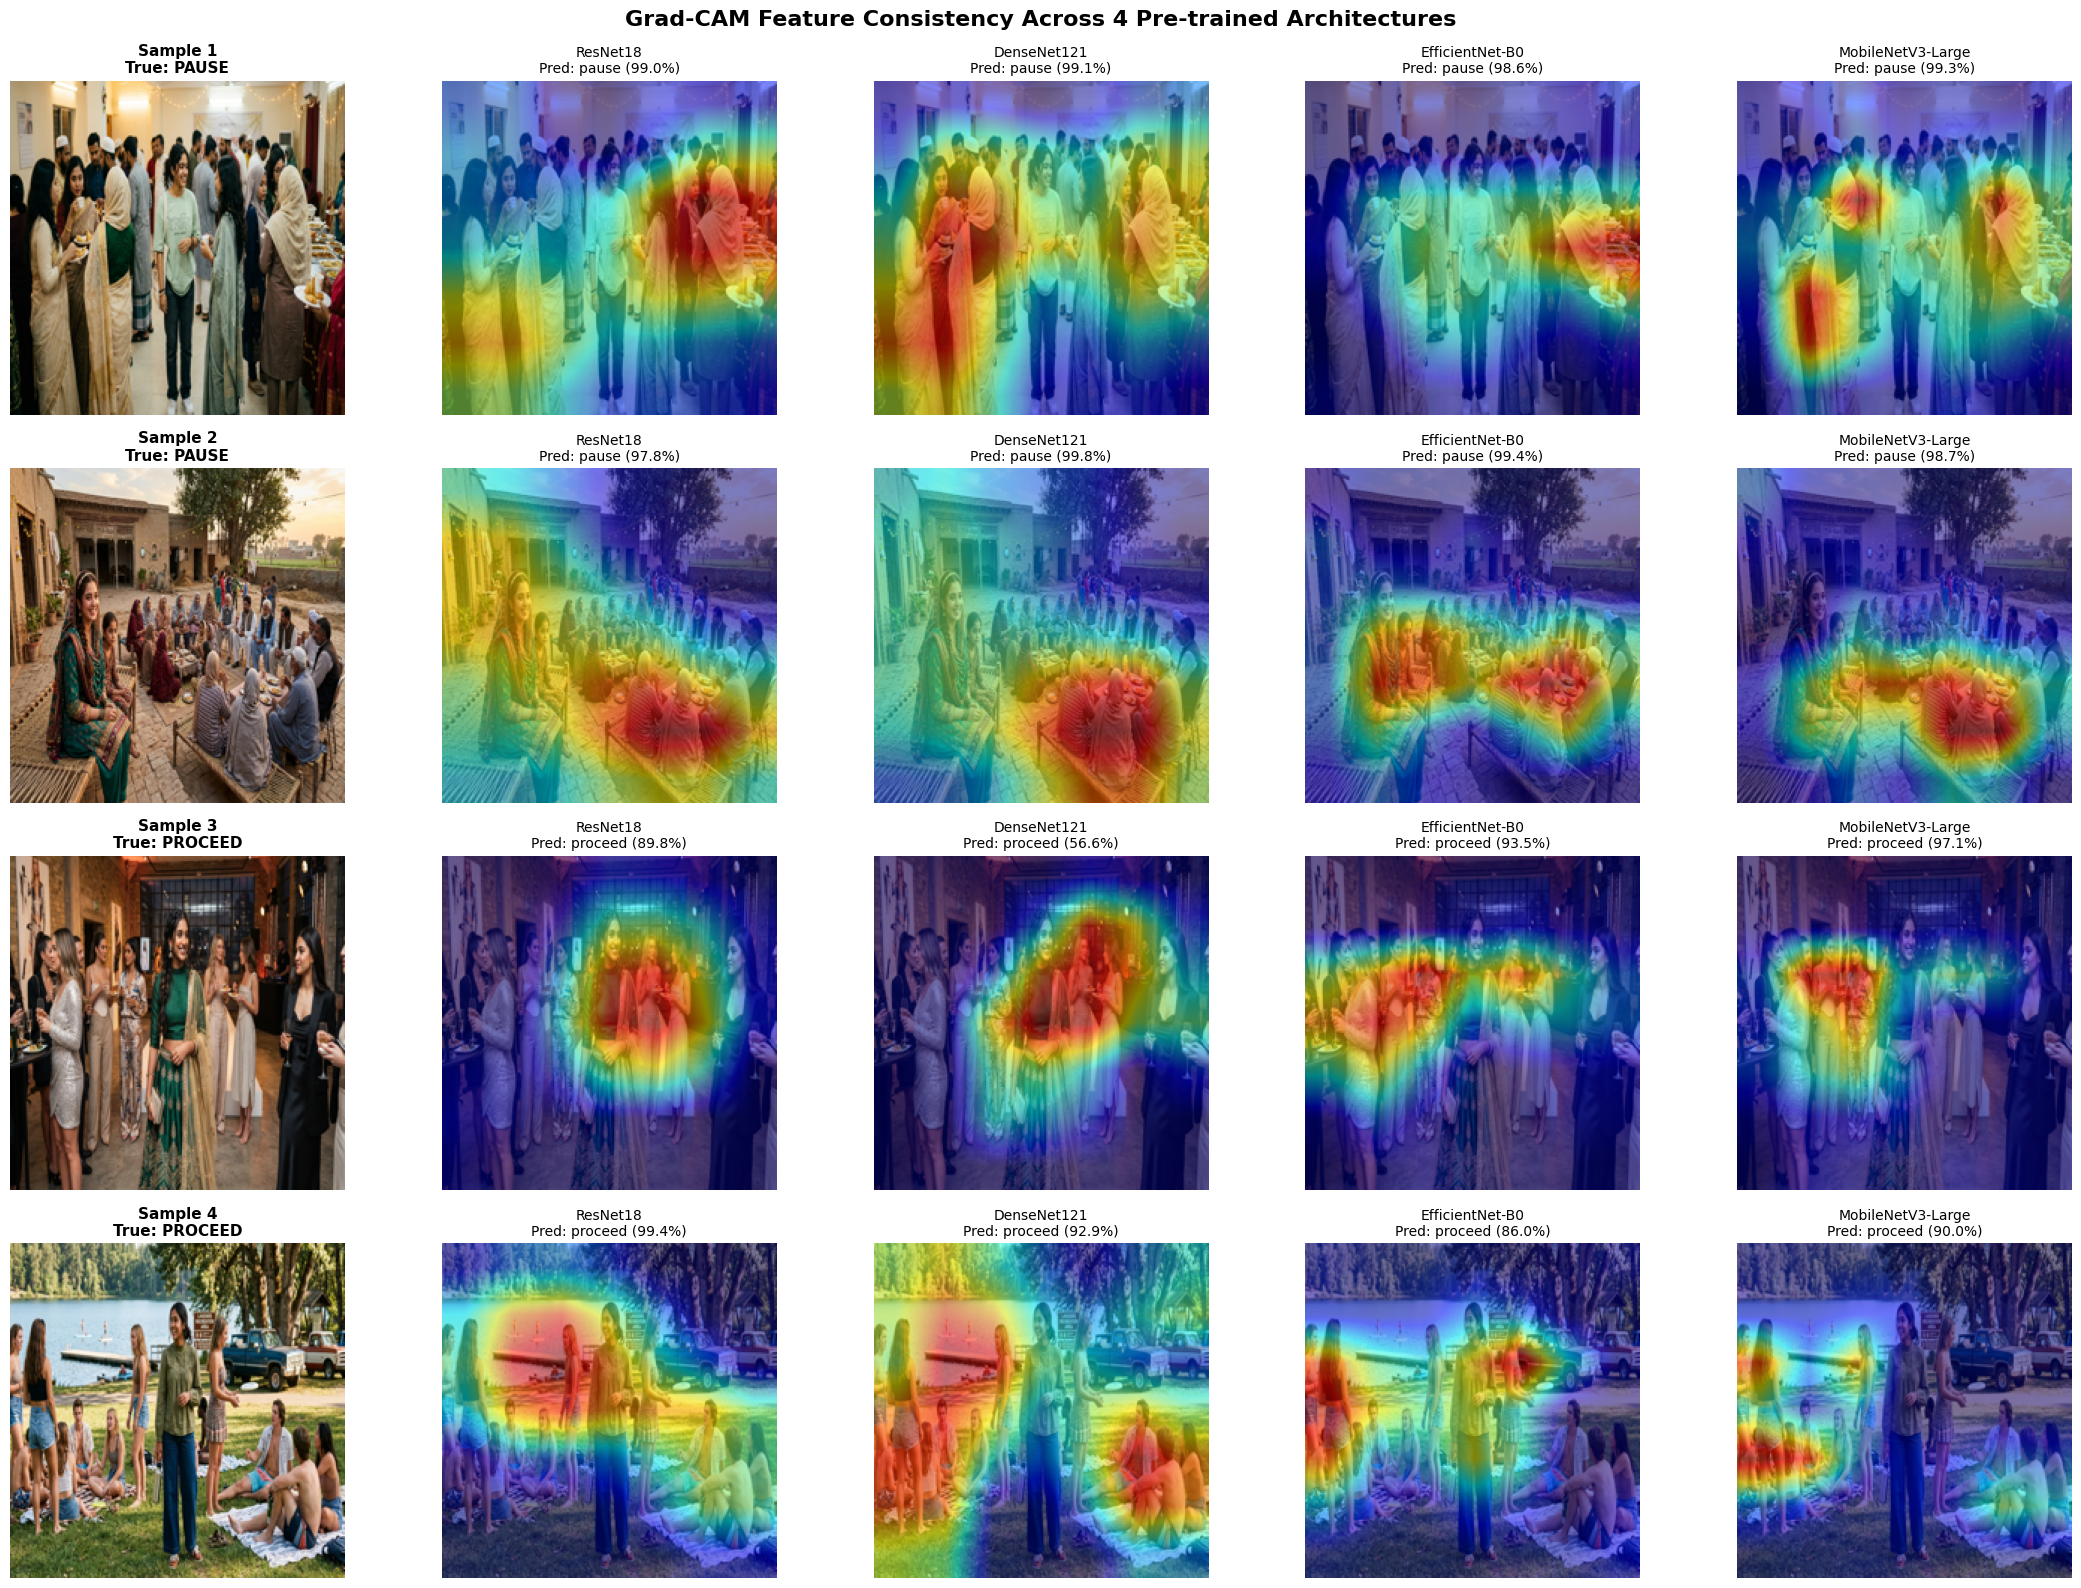

In [ ]:
# 1. Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Drive & Params
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/safe-llm-for-women'

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# 3. Standard Transform (No random augmentations)
standard_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=standard_transforms)
raw_dataset = datasets.ImageFolder(root=DATA_DIR, transform=None)
class_names = dataset.classes
targets = dataset.targets

# 4. Stratified 80/20 Split
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    shuffle=True,
    stratify=targets,
    random_state=42
)

train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
val_raw_subset = Subset(raw_dataset, val_idx)

print(f"Classes: {class_names}")
print(f"Train samples: {len(train_idx)} | Validation samples: {len(val_idx)}")

def build_model(model_name, num_classes=2):
    if model_name == 'ResNet18':
        net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        net.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.fc.in_features, num_classes))
        target_layer = [net.layer4[-1]]
    elif model_name == 'DenseNet121':
        net = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        net.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.classifier.in_features, num_classes))
        target_layer = [net.features[-1]]
    elif model_name == 'EfficientNet-B0':
        net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        net.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.classifier[1].in_features, num_classes))
        target_layer = [net.features[-1]]
    elif model_name == 'MobileNetV3-Large':
        net = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        net.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(net.classifier[0].in_features, num_classes))
        target_layer = [net.features[-1]]
    return net.to(device), target_layer

MODEL_NAMES = ['ResNet18', 'DenseNet121', 'EfficientNet-B0', 'MobileNetV3-Large']
trained_models = {}
target_layers_dict = {}
histories = {}
val_preds_dict = {}
val_labels_dict = {}

criterion = nn.CrossEntropyLoss()

for name in MODEL_NAMES:
    print(f"\n{'='*20} Training {name} (10 Epochs) {'='*20}")
    set_seed(42)
    model, target_layer = build_model(name)
    target_layers_dict[name] = target_layer
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_loss = float('inf')
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(EPOCHS):
        # Training Phase
        model.train()
        train_loss, train_correct = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            train_correct += torch.sum(out.argmax(1) == y.data)

        epoch_train_loss = train_loss / len(train_idx)
        epoch_train_acc = (train_correct.double() / len(train_idx)).item()

        # Validation Phase
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)
                val_correct += torch.sum(out.argmax(1) == y.data)

        epoch_val_loss = val_loss / len(val_idx)
        epoch_val_acc = (val_correct.double() / len(val_idx)).item()

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        # Real-time epoch print
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            best_wts = copy.deepcopy(model.state_dict())

    # Load best checkpoint
    model.load_state_dict(best_wts)
    trained_models[name] = model
    histories[name] = history

    # Evaluate best model on Validation Set
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            out = model(x)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    val_preds_dict[name] = preds
    val_labels_dict[name] = labels
    print(f">> {name} Done! Best Val Loss: {best_loss:.4f} | Best Val Acc: {np.mean(np.array(preds) == np.array(labels)):.2%}\n")

pause_idx = class_names.index('pause')
proceed_idx = class_names.index('proceed')

# Find 2 True Pause & 2 True Proceed correctly classified by all 4 models
pause_samples, proceed_samples = [], []
for idx in range(len(val_raw_subset)):
    raw_img, label = val_raw_subset[idx]
    inp = standard_transforms(raw_img).unsqueeze(0).to(device)

    preds = [trained_models[m](inp).argmax(1).item() for m in MODEL_NAMES]

    if label == pause_idx and all(p == pause_idx for p in preds) and len(pause_samples) < 2:
        pause_samples.append(idx)
    elif label == proceed_idx and all(p == proceed_idx for p in preds) and len(proceed_samples) < 2:
        proceed_samples.append(idx)

    if len(pause_samples) == 2 and len(proceed_samples) == 2:
        break

selected_samples = pause_samples + proceed_samples

# Setup GradCAM instances
cams = {name: GradCAM(model=trained_models[name], target_layers=target_layers_dict[name]) for name in MODEL_NAMES}

# Plot: 4 Rows x 5 Columns
fig, axes = plt.subplots(4, 5, figsize=(22, 16))

for row_idx, sample_idx in enumerate(selected_samples):
    raw_img, label = val_raw_subset[sample_idx]
    resized_img = raw_img.resize((IMG_SIZE, IMG_SIZE))
    rgb_img = np.float32(resized_img) / 255.0
    input_tensor = standard_transforms(raw_img).unsqueeze(0).to(device)

    # Column 0: Original Ground Truth Image
    axes[row_idx, 0].imshow(resized_img)
    axes[row_idx, 0].set_title(f"Sample {row_idx+1}\nTrue: {class_names[label].upper()}", fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # Columns 1 to 4: Grad-CAM for each model
    for col_idx, name in enumerate(MODEL_NAMES, start=1):
        model = trained_models[name]
        cam = cams[name]

        with torch.no_grad():
            out = model(input_tensor)
            prob = F.softmax(out, dim=1)
            pred = out.argmax(dim=1).item()
            conf = prob[0][pred].item() * 100

        targets = [ClassifierOutputTarget(pred)]
        cam_map = cam(input_tensor=input_tensor, targets=targets)[0, :]
        vis = show_cam_on_image(rgb_img, cam_map, use_rgb=True)

        axes[row_idx, col_idx].imshow(vis)
        axes[row_idx, col_idx].set_title(f"{name}\nPred: {class_names[pred]} ({conf:.1f}%)", fontsize=10)
        axes[row_idx, col_idx].axis('off')

plt.suptitle("Grad-CAM Feature Consistency Across 4 Pre-trained Architectures", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()